**Lab 03: FEATURE DETECTION AND IMAGE MATCHING**

In [9]:
# Khai báo thư viện ảnh
import cv2
import matplotlib.pyplot as TenSV

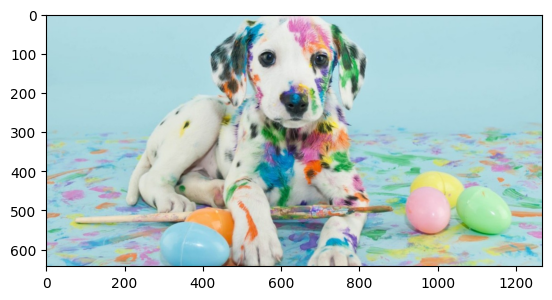

In [10]:
# Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu
img = cv2.imread('hinh1.jpg')
img = img[:,:,::-1]
TenSV.imshow(img)

1. Thực hành xử lý ảnh trong miền tần số:
- Fast Fourier Transform (FFT) algorithm để phát hiện ảnh mờ.
- Để đọc ảnh và hiển thị ảnh, ta dùng matplotlib

In [11]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [12]:
# Đọc bức ảnh và đưa về float32
img = cv2.imread('hinh1.jpg',0)
img_float32 = np.float32(img)

In [ ]:
# Sau đó đưa ảnh về dạng số phức, và dùng fft có sẵn trong numpy để biến đổi để được biên độ của các sóng với các tần số khác nhau.
dft = cv2.dft(img_float32, flags =
            cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

In [21]:
# Đưa về thang log, rồi khuếch đại lên 20 lần để vẽ. 
# Nếu không đưa về thang log, các sóng ở tâm sẽ rất lớn, và sẽ lấn át các sóng có tần số cao và khi biểu diễn chỉ có điểm sáng ở giữa, còn lại tối hết. 
# Đưa về thang log để biên độ chênh lệch giữa các sóng được giảm xuống. 
# Ta khuếch đại lên 1 chút (20 lần) để tăng độ tương phản cho bức ảnh. 
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

**2. Sử dụng đoạn code sau cho DFT, trình bày ý nghĩa của từng dòng lệnh.**

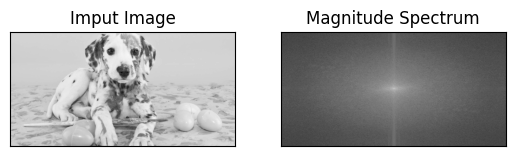

In [14]:
plt.subplot(121), plt.imshow(img, cmap = 'gray')
plt.title('Imput Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

**3. Sử dụng Fast Fourier Transform (FFT) Magnitude algorithm để phát hiện ảnh mờ**

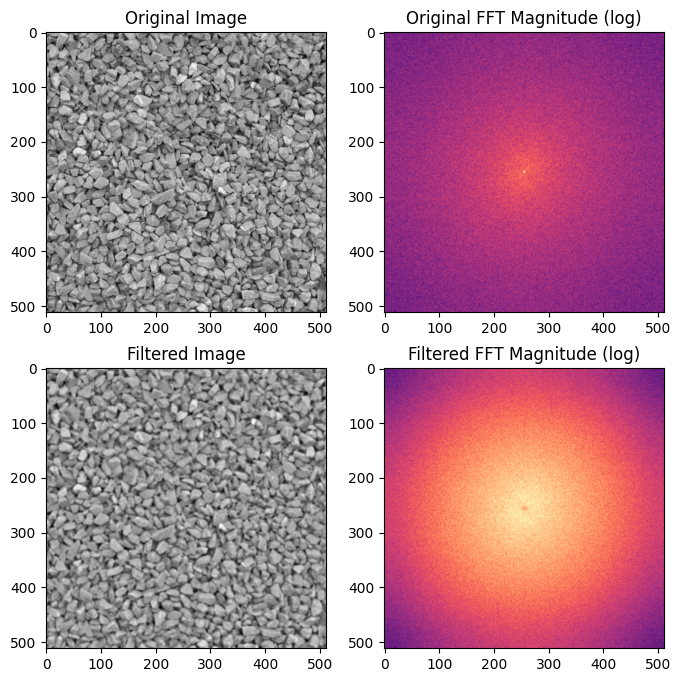

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

image = gravel()
wimage = image * window('hann', image.shape)  # window image to improve FFT
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')

plt.show()

In [16]:
# Thực hành Harris Corner Detection
import cv2
import numpy as np
from IPython.display import Image
def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray, blockSize, ksize, k)

    #result is dilated for marking the corners, not important
    dst = cv2.dilate(dst, None)

    # Threshold for an optimal value, it may vary depending on the image.
    img[dst>threshold*dst.max()]=[0, 0, 255]
    cv2.imwrite('example.jpg',img)
    return img

out_path = detect_corner('hinh1.jpg', blockSize=2, ksize=5, k=0.04, threshold=0.005)

Image(out_path)

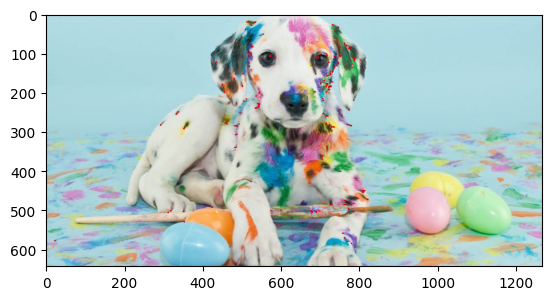

In [19]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('hinh1.jpg')
plt.imshow(img[:,:,::-1])

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray,2,3,0.04)
dst = cv2.dilate(dst,None)
img[dst>0.01*dst.max()] = [0,0,225]

plt.imshow(img[:,:,::-1])

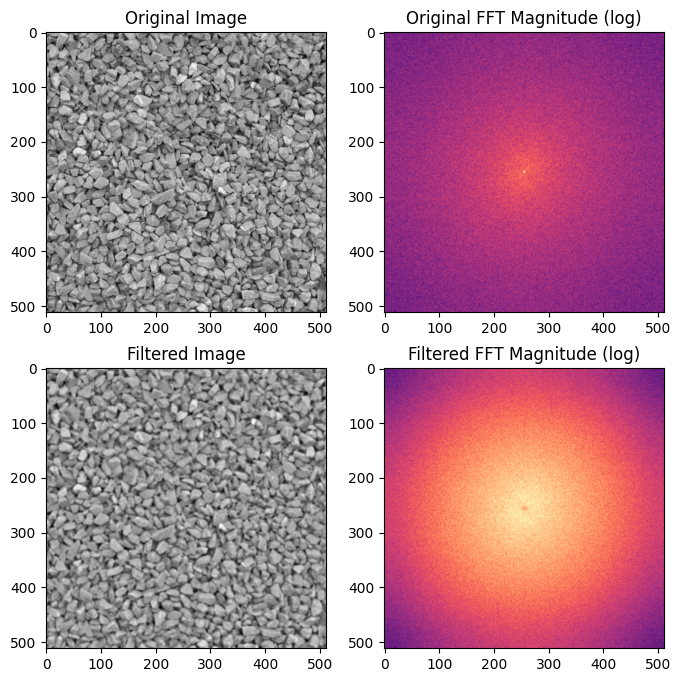

In [20]:
# Band-pass filtering by Difference of Gaussians
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

image = gravel()
wimage = image * window('hann', image.shape)  # window image to improve FFT
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)
im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')

plt.show()